### **Importing Libraries**

In [ ]:
import json

### **Importing Data**

In [ ]:
# Open the JSON file and load its content
with open('/content/passport_data(200).json', 'r') as f:
    all_records = json.load(f)

print(f"Total passport records loaded: {len(all_records)}")
print("First record:", all_records[0])

Total passport records loaded: 200
First record: {'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}


In [ ]:
# Print last 5 records
for i, record in enumerate(all_records[-5:], 1):
    record_no_file = {k: v for k, v in record.items() if k != "_filename"}
    print(f"Record {i}: {record_no_file}")

Record 1: {'surname': None, 'given_name': 'KUMARI PRIYANKA', 'nationality': 'INDIAN', 'sex': 'F', 'date_of_birth': '11 JAN 1990', 'place_of_birth': 'RATANPUR, BIHAR', 'place_of_issue': 'PATNA'}
Record 2: {'surname': 'BHAVSAR', 'given_name': 'PRASANNAKUMAR ASHOK', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '26 NOV 1982', 'place_of_birth': 'MUMBAI MS', 'place_of_issue': 'MUMBAI'}
Record 3: {'surname': 'KARAMPUDI', 'given_name': 'VENKATA PAVAN', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '19 NOV 1992', 'place_of_birth': 'PONNUR, ANDHRA PRADESH', 'place_of_issue': 'HYDERABAD'}
Record 4: {'surname': 'SAYARI', 'given_name': 'CHANDANA', 'nationality': 'INDIAN', 'sex': 'F', 'date_of_birth': '28 JAN 1992', 'place_of_birth': 'HYDERABAD, TELANGANA', 'place_of_issue': 'HYDERABAD'}
Record 5: {'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '15 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDD

### **Data preprocessing**

In [ ]:
# Function to check null or empty
def is_missing(value):
    return value is None or str(value).strip() == ""

# Lists to store records
missing_surname = []
missing_given_name = []
missing_dob = []
missing_nationality = []
missing_sex = []
missing_place_of_birth = []
missing_place_of_issue = []

for rec in all_records:
    if is_missing(rec.get("surname")):
        missing_surname.append(rec)

    if is_missing(rec.get("given_name")):
        missing_given_name.append(rec)

    if is_missing(rec.get("date_of_birth")):
        missing_dob.append(rec)

    if is_missing(rec.get("nationality")):
        missing_nationality.append(rec)

    if is_missing(rec.get("sex")):
        missing_sex.append(rec)

    if is_missing(rec.get("place_of_birth")):
        missing_place_of_birth.append(rec)

    if is_missing(rec.get("place_of_issue")):
        missing_place_of_issue.append(rec)

# Print lengths
print("Missing surname:", len(missing_surname))
print("Missing given_name:", len(missing_given_name))
print("Missing date_of_birth:", len(missing_dob))
print("Missing nationality:", len(missing_nationality))
print("Missing sex:", len(missing_sex))
print("Missing place_of_birth:", len(missing_place_of_birth))
print("Missing place_of_issue:", len(missing_place_of_issue))
print(f"Total passport records loaded: {len(all_records)}")


Missing surname: 22
Missing given_name: 1
Missing date_of_birth: 1
Missing nationality: 1
Missing sex: 1
Missing place_of_birth: 1
Missing place_of_issue: 1
Total passport records loaded: 200


## **Visualizing Network graph for any similar nodes**

In [ ]:
import networkx as nx
from difflib import SequenceMatcher

# Similarity function
def ratio(a, b):
    return SequenceMatcher(None, a, b).ratio()

# Initialize graph
G = nx.Graph()

# Precompute full names
full_names = []
for rec in all_records:
    name = f"{rec.get('given_name','')} {rec.get('surname','')}".strip()
    full_names.append(name.lower())

# Add nodes
for i, rec in enumerate(all_records):
    G.add_node(
        i,
        name=full_names[i],
        dob=rec.get("date_of_birth"),
        pob=rec.get("place_of_birth"),
        poi=rec.get("place_of_issue"),
        nationality=rec.get("nationality"),
        sex=rec.get("sex")
    )

# Create edges (ONLY STRONG MATCHES)
for i in range(len(all_records)):
    r1 = all_records[i]

    for j in range(i + 1, len(all_records)):
        r2 = all_records[j]

        reasons = []

        name_sim = ratio(full_names[i], full_names[j])

        dob1 = r1.get("date_of_birth")
        dob2 = r2.get("date_of_birth")

        pob1 = r1.get("place_of_birth")
        pob2 = r2.get("place_of_birth")

        # Rule 1: Exact Name + DOB
        if full_names[i] == full_names[j] and dob1 and dob1 == dob2:
            reasons.append("name_dob_match")

        # Rule 2: Very high name similarity + same DOB
        elif name_sim > 0.90 and dob1 and dob1 == dob2:
            reasons.append("similar_name_dob")

        # Rule 3: Very high name similarity + same place of birth
        elif name_sim > 0.92 and pob1 and pob1 == pob2:
            reasons.append("similar_name_pob")

        # Add edge only if strong rule satisfied
        if reasons:
            G.add_edge(i, j, reason=",".join(reasons))

# Node coloring based on connections
node_colors = []
for node in G.nodes():
    degree = G.degree[node]

    if degree >= 3:
        node_colors.append("red")       # strong suspicious cluster
    elif degree >= 1:
        node_colors.append("orange")    # possible duplicate
    else:
        node_colors.append("skyblue")   # isolated

print("Graph created with nodes:", G.number_of_nodes(), "and edges:", G.number_of_edges())

Graph created with nodes: 200 and edges: 61


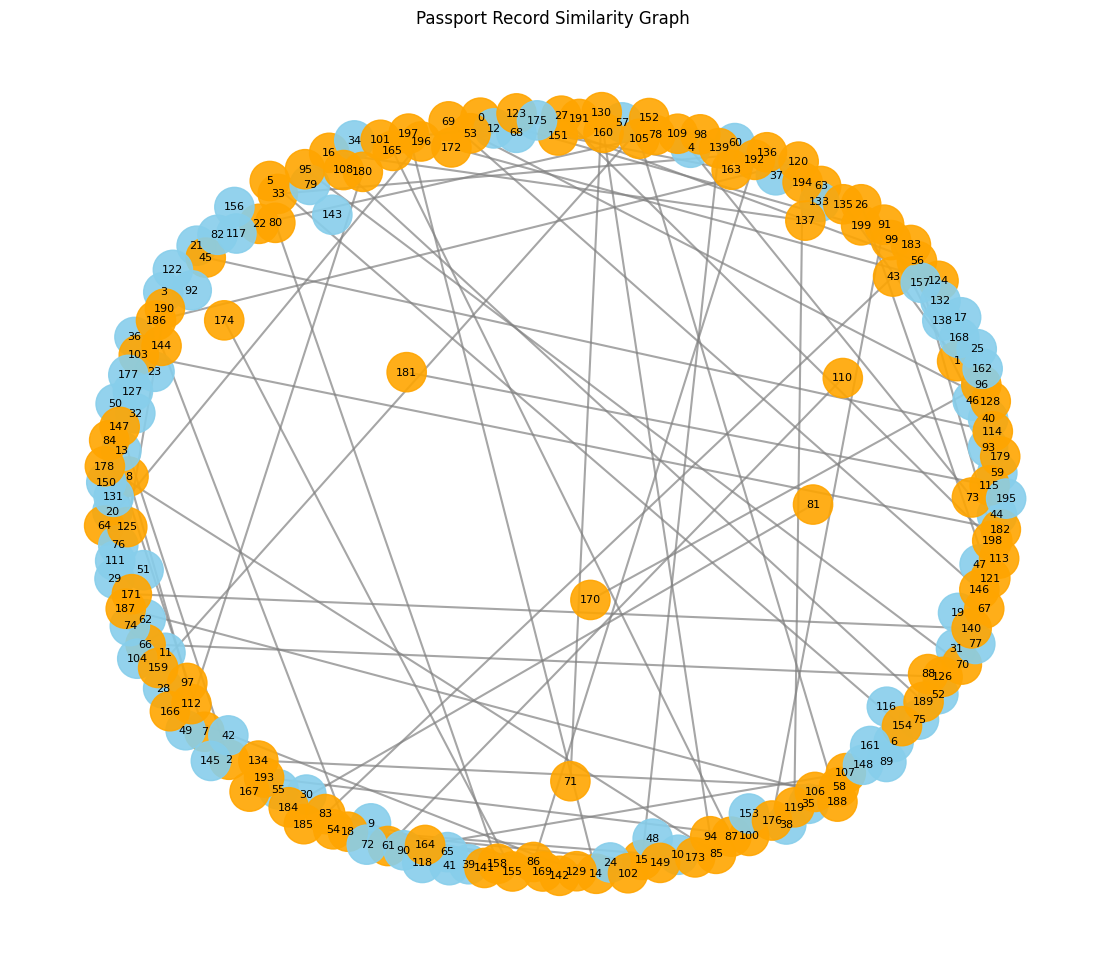

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,12))   # bigger canvas

# Increase spacing between nodes
pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42)

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=800,
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    width=1.5,
    alpha=0.7
)

nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title("Passport Record Similarity Graph")
plt.axis("off")   # removes axis for cleaner graph
plt.show()

## **Training the GNN model**

**Install libraries**

In [ ]:
!pip install sentence-transformers torch-geometric

**Import libraries**

In [ ]:
# Convert NetworkX graph to PyTorch Geometric format
from torch_geometric.utils import from_networkx
data = from_networkx(G)

In [ ]:
# Load Sentence Transformer model
from sentence_transformers import SentenceTransformer
model_embed = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Data Preprocessing**

In [ ]:
# Prepare text fields for embeddings
names = [
    f"{rec.get('given_name','')} {rec.get('surname','')}".strip()
    for rec in all_records
]

places_birth = [
    rec.get("place_of_birth","") if rec.get("place_of_birth") else ""
    for rec in all_records
]

places_issue = [
    rec.get("place_of_issue","") if rec.get("place_of_issue") else ""
    for rec in all_records
]


# Generate embeddings
name_vectors = model_embed.encode(names)
birth_place_vectors = model_embed.encode(places_birth)
issue_place_vectors = model_embed.encode(places_issue)

In [ ]:
# Extract numeric features
numeric_features = []

for rec in all_records:

    # Sex encoding
    sex_map = {"M":1, "F":2}
    sex = sex_map.get(rec.get("sex"), 0)

    # Nationality encoding
    nationality = rec.get("nationality","")
    nationality_num = sum([ord(c) for c in nationality]) % 1000 if nationality else 0

    # DOB extraction
    day = 0
    month = 0
    year = 0

    dob = rec.get("date_of_birth","")

    if dob:
        try:
            parts = dob.split()

            if len(parts) == 3:
                day = int(parts[0])
                year = int(parts[2])

                month_map = {
                    "JAN":1,"FEB":2,"MAR":3,"APR":4,"MAY":5,"JUN":6,
                    "JUL":7,"AUG":8,"SEP":9,"OCT":10,"NOV":11,"DEC":12
                }

                month = month_map.get(parts[1].upper(),0)

        except:
            pass

    numeric_features.append([sex, nationality_num, day, month, year])


import numpy as np
numeric_features = np.array(numeric_features)

In [ ]:
# Combine all features
features = np.concatenate([
    name_vectors,
    birth_place_vectors,
    issue_place_vectors,
    numeric_features
], axis=1)

In [ ]:
# Normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [ ]:

# Convert to PyTorch tensor
import torch
X = torch.tensor(features, dtype=torch.float)

In [ ]:

# Assign features to graph
data = from_networkx(G)
data.x = X


In [ ]:
# Check feature shape
print("Passport feature tensor shape:", data.x.shape)

Passport feature tensor shape: torch.Size([200, 1157])


In [ ]:
# Show feature vector for the first record
record_index = 0
print(f"Feature vector for record {record_index+1}:")
print()
print(X[record_index])

Feature vector for record 1:

tensor([0.2623, 1.1596, 0.2697,  ..., 0.0548, 1.5637, 0.7818])


**Training the GNN model**

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GNN(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)
        self.conv2 = GCNConv(128, 64)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

In [ ]:
# 2️ Initialize model
in_dim = X.shape[1]   # feature vector size
model = GNN(in_channels=in_dim)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:

# 3️ Train the model
for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    # Unsupervised anomaly learning
    loss = torch.mean(out**2)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.1529862880706787
Epoch: 20 Loss: 0.0591244138777256
Epoch: 40 Loss: 0.006733284797519445
Epoch: 60 Loss: 0.0010318865533918142
Epoch: 80 Loss: 0.0021829509641975164
Epoch: 100 Loss: 0.0006799359689466655
Epoch: 120 Loss: 0.004165173973888159
Epoch: 140 Loss: 0.00047733524115756154
Epoch: 160 Loss: 0.008810040540993214
Epoch: 180 Loss: 0.00015674698806833476


In [ ]:
# 4️ Compute anomaly scores
model.eval()

with torch.no_grad():
    embeddings = model(data.x, data.edge_index)

    # L2 norm → anomaly score
    scores = torch.norm(embeddings, dim=1)

print("\n--- Passport Record Anomaly Scores ---\n")

for i, s in enumerate(scores):
    print(f"Record {i}: Anomaly Score = {float(s):.4f}")


--- Passport Record Anomaly Scores ---

Record 0: Anomaly Score = 0.0221
Record 1: Anomaly Score = 0.0196
Record 2: Anomaly Score = 0.0183
Record 3: Anomaly Score = 0.0389
Record 4: Anomaly Score = 0.0377
Record 5: Anomaly Score = 0.0189
Record 6: Anomaly Score = 0.0878
Record 7: Anomaly Score = 0.0246
Record 8: Anomaly Score = 0.0256
Record 9: Anomaly Score = 0.0364
Record 10: Anomaly Score = 0.0187
Record 11: Anomaly Score = 0.0689
Record 12: Anomaly Score = 0.0495
Record 13: Anomaly Score = 0.0446
Record 14: Anomaly Score = 0.0177
Record 15: Anomaly Score = 0.0233
Record 16: Anomaly Score = 0.0539
Record 17: Anomaly Score = 0.0311
Record 18: Anomaly Score = 0.0222
Record 19: Anomaly Score = 0.0379
Record 20: Anomaly Score = 0.0270
Record 21: Anomaly Score = 0.0441
Record 22: Anomaly Score = 0.0490
Record 23: Anomaly Score = 0.0761
Record 24: Anomaly Score = 0.0619
Record 25: Anomaly Score = 0.0259
Record 26: Anomaly Score = 0.0555
Record 27: Anomaly Score = 0.0410
Record 28: Anomal

**Saving the model**

In [ ]:
# 6️ Save the trained model
torch.save(model.state_dict(), "passport_gnn_model.pth")

In [ ]:
# 7️ Load the model later (if needed)
model.load_state_dict(torch.load("passport_gnn_model.pth"))
model.eval()

GNN(
  (conv1): GCNConv(1157, 128)
  (conv2): GCNConv(128, 64)
)

**Testing on Single sample**

In [ ]:
# Select one passport record from the dataset
record_index = 0
rec = all_records[record_index]
print("Testing record:")

Testing record:


In [ ]:
# Function to extract numeric passport features (same logic used during training)
def extract_numeric_features_passport(rec):

    # Encode sex: M=1, F=2, unknown=0
    sex_map = {"M":1, "F":2}
    sex = sex_map.get(rec.get("sex"), 0)

    # Convert nationality text to a numeric representation
    nationality = rec.get("nationality", "")
    nationality_num = sum([ord(c) for c in nationality]) % 1000 if nationality else 0

    # Initialize DOB values
    day, month, year = 0, 0, 0
    dob = rec.get("date_of_birth", "")

    # Extract day, month, year from DOB
    if dob:
        try:
            parts = dob.split()
            if len(parts) == 3:
                day = int(parts[0])
                year = int(parts[2])

                # Convert month text to numeric value
                month_map = {
                    "JAN":1,"FEB":2,"MAR":3,"APR":4,"MAY":5,"JUN":6,
                    "JUL":7,"AUG":8,"SEP":9,"OCT":10,"NOV":11,"DEC":12
                }

                month = month_map.get(parts[1].upper(),0)
        except:
            pass

    return np.array([sex, nationality_num, day, month, year])


In [ ]:
# Convert passport text fields to embeddings
name = [rec.get("name", "")]
birth_place = [rec.get("place_of_birth", "")]
issue_place = [rec.get("place_of_issue", "")]

name_vec = model_embed.encode(name)
birth_vec = model_embed.encode(birth_place)
issue_vec = model_embed.encode(issue_place)

In [ ]:
# Extract numeric passport features
numeric = extract_numeric_features_passport(rec).reshape(1, -1)

# Combine embeddings and numeric features into a single feature vector
features_combined = np.concatenate([
    name_vec,
    birth_vec,
    issue_vec,
    numeric
], axis=1)

# Normalize the features using the same scaler used during training
features_scaled = scaler.transform(features_combined)

# Convert the feature vector into a PyTorch tensor
sample_x = torch.tensor(features_scaled, dtype=torch.float)

# Create an empty graph edge index since this is a single isolated node
empty_edge_index = torch.empty((2,0), dtype=torch.long)

# Run the GNN model to compute embeddings and anomaly score
model.eval()
with torch.no_grad():
    embeddings = model(sample_x, empty_edge_index)
    score = torch.norm(embeddings, dim=1).item()

print("Anomaly Score:", score)

Anomaly Score: 4.291839122772217


In [69]:
# In general how we should put threshold
scores_np = scores.numpy()
print("Max score in training:", scores_np.max())
print("Mean score:", scores_np.mean())
print("Std:", scores_np.std())
threshold = scores_np.mean() + 3*scores_np.std()
print(threshold)

Max score in training: 0.12420333
Mean score: 0.044518895
Std: 0.024435975
0.11782682


In [70]:
# Decide whether the passport record is normal or suspicious
threshold = 0.1
if score > threshold:
    print("☑ Suspicious Passport Record")
else:
    print("✅ Normal Passport Record")

# Print the passport record details

☑ Suspicious Passport Record


In [ ]:
print(rec)

{'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}


In [ ]:
# Print details of the input Passport record
print("Input Passport Record:")
print(rec)
print()

# Normalize vectors for cosine similarity
sample_norm = F.normalize(sample_x, dim=1)
nodes_norm = F.normalize(data.x, dim=1)

# Compute similarity scores between input passport and dataset passports
similarities = torch.mm(sample_norm, nodes_norm.T)

# Get top 5 most similar passport records
top_k = 5
values, indices = torch.topk(similarities, top_k)

print("Most similar Passport records in dataset:")

for i in range(top_k):
    node_id = indices[0][i].item()
    sim_score = values[0][i].item()
    rec_sim = all_records[node_id]

    print(f"Node {node_id}  Similarity: {sim_score:.4f}")
    print(rec_sim)  # print full passport record
    print()

Input Passport Record:
{'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}

Most similar Passport records in dataset:
Node 0  Similarity: 0.5716
{'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}

Node 199  Similarity: 0.5715
{'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '15 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}

Node 89  Similarity: 0.3999
{'surname': '', 'given_name': '', 'nationality': '', 'sex': '', 'date_of_birth': '', 'place_of_birth': '', 'place_of_issue': ''}

Node 158  Similarity: 0.2618
{'surname': 'SARABHAI', 'given_name': 'ANAHITA', 'nationality': 'INDIAN', 'sex': 'F', 'date_of_birth': '26 MAY